# 随机变量的概率计算和数字特征

### 1. 随机变量的概率计算

$$
\textbf{定义 4.1} \quad \alpha \text{ 分位数} \quad \text{若连续型随机变量 } X \text{ 的分布函数为 } F(x), \text{ 对于 } 0 < \alpha < 1, \text{ 若 } x_\alpha \text{ 使得 } P\{X \leq x_\alpha\} = \alpha, \text{ 则称 } x_\alpha \text{ 为这个分布的 } \alpha \text{ 分位数. 若 } F(x) \text{ 的反函数 } F^{-1}(x) \text{ 存在，则有 } x_\alpha = F^{-1}(\alpha).
$$

$$
\textbf{定义 4.2} \quad \text{上 } \alpha \text{ 分位数} \quad \text{若连续型随机变量 } X \text{ 的分布函数为 } F(x), \text{ 对于 } 0 < \alpha < 1, \text{ 若 } \tilde{x}_\alpha \text{ 使得 } P\{X > \tilde{x}_\alpha\} = \alpha, \text{ 则称 } \tilde{x}_\alpha \text{ 为这个分布的上 } \alpha \text{ 分位数. 若 } F(x) \text{ 的反函数 } F^{-1}(x) \text{ 存在，则 } \tilde{x}_\alpha = F^{-1}(1 - \alpha).
$$



$$
\text{设 } X \sim N(3, 5^2), \\
\begin{aligned}
&(1) \text{ 求 } P\{2 < X < 6\}; \\
&(2) \text{ 确定 } c, \text{ 使得 } P\{-3c < X < 2c\} = 0.6.
\end{aligned}
$$

In [6]:
from scipy.stats import norm
from scipy.optimize import fsolve
print(f"p={norm.cdf(6, 3, 5)-norm.cdf(2, 3, 5)}")
f = lambda c: norm.cdf(2*c, 3, 5)-norm.cdf(-3*c, 3, 5)-0.6
print(f"c={fsolve(f, 0)}")

p=0.3050065916890295
c=[2.29103356]


$$
\text{设 } X \sim N(0, 1), \text{ 若 } z_\alpha \text{ 满足条件 } P\{X > z_\alpha\} = \alpha, \ 0 < \alpha < 1, \text{ 则称 } z_\alpha \text{ 为标准正态分布的上 } \alpha \text{ 分位数. 试计算几个常用的 } z_\alpha \text{ 的值，并画出 } z_{0.1} \text{ 的示意图.}
$$

$$
\text{计算得到几个常用的 } z_\alpha \text{ 的值见表 4.1, } z_{0.1} \text{ 的示意图见图 4.1.}
$$

$$
\textbf{表 4.1} \quad \text{标准正态分布的上 } \alpha \text{ 分位数的值}
$$

$$
\begin{array}{c|c|c|c|c|c|c}
\hline
\alpha & 0.001 & 0.005 & 0.01 & 0.025 & 0.05 & 0.10 \\
\hline
z_\alpha & 3.0902 & 2.5758 & 2.3263 & 1.9600 & 1.6449 & 1.2816 \\
\hline
\end{array}
$$

上alpha分位数分别为：[3.09023231 2.5758293  2.32634787 1.95996398 1.64485363 1.28155157]


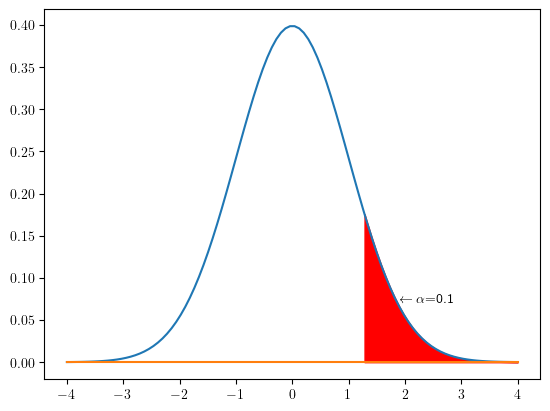

In [14]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
alpha = np.array([0.001, 0.005, 0.01, 0.025, 0.05, 0.10])
# z_alpha = np.array([3.0902, 2.5758, 2.3263, 1.9600, 1.6449, 1.2816])
za = norm.ppf(1-alpha, 0, 1)  # 求上alpha分位数，对称性
print(f"上alpha分位数分别为：{za}")
x = np.linspace(-4, 4, 100)
y = norm.pdf(x, 0, 1)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['text.usetex'] = True
plt.plot(x, y)
x2 = np.linspace(za[-1], 4, 100)
y2 = norm.pdf(x2)
y1 = [0]*len(x2)
plt.fill_between(x2, y1, y2, color='r')
plt.plot([-4, 4], [0, 0])
plt.text(1.9, 0.07, r"$\leftarrow\alpha$=0.1")
plt.savefig("正态.png", dpi=500)
plt.show()

### 2. 随机变量数字特征简介

定义 4.3 设随机变量 $X$ 的分布律为
$$
P\{X = x_k\} = p_k,\quad k = 1, 2, \cdots,
$$
若级数 $\sum_{k=1}^{\infty} x_k p_k$ 绝对收敛，则称级数 $\sum_{k=1}^{\infty} x_k p_k$ 的和为随机变量 $X$ 的数学期望，记为 $E(X)$，即
$$
E(X) = \sum_{k=1}^{\infty} x_k p_k.\tag{4.1}
$$

设连续型随机变量 $X$ 的概率密度为 $f(x)$，若积分 $\int_{-\infty}^{+\infty} x f(x) dx$ 绝对收敛，则称积分 $\int_{-\infty}^{+\infty} x f(x) dx$ 的值为随机变量 $X$ 的数学期望，记为 $E(X)$。即
$$
E(X) = \int_{-\infty}^{+\infty} x f(x) dx.\tag{4.2}
$$

定义 4.4 设 $X$ 是一个随机变量，若 $E\{[X - E(X)]^2\}$ 存在，则称 $E\{[X - E(X)]^2\}$ 为 $X$ 的方差，记为 $D(X)$ 或 $\text{Var}(X)$，即
$$
D(X) = \text{Var}(X) = E\{[X - E(X)]^2\}.\tag{4.3}
$$
$\sigma(x) = \sqrt{D(X)}$，称为标准差或均方差.

由定义 4.4 知，方差实际上就是随机变量 $X$ 的函数 $g(X) = (X - E(X))^2$ 的数学期望.

定义 4.5 随机变量 $X$ 的偏度和峰度指的是 $X$ 的标准化变量 $\frac{(X - E(X))}{\sqrt{D(X)}}$ 的三阶中心矩和四阶中心矩：
$$
\nu_1 = E\left[\left(\frac{X - E(X)}{\sqrt{D(X)}}\right)^3\right] = \frac{E\left[(X - E(X))^3\right]}{(D(X))^{3/2}},
$$
$$
\nu_2 = E\left[\left(\frac{X - E(X)}{\sqrt{D(X)}}\right)^4\right] = \frac{E\left[(X - E(X))^4\right]}{(D(X))^2}.
$$

定义 4.6 $E\{[X - E(X)][Y - E(Y)]\}$ 称为随机变量 $X$ 与 $Y$ 的协方差. 记为 $\text{Cov}(X, Y)$，即
$$
\text{Cov}(X, Y) = E\{[X - E(X)][Y - E(Y)]\},\tag{4.4}
$$
而
$$
\rho_{XY} = \frac{\text{Cov}(X, Y)}{\sqrt{D(X)}\sqrt{D(Y)}}\tag{4.5}
$$
称为随机变量 $X$ 与 $Y$ 的相关系数.

定义 4.7 设 $X$ 和 $Y$ 是随机变量，若 $E(X^k), k = 1, 2, \cdots$ 存在，称它为 $X$ 的 $k$ 阶原点矩，简称 $k$ 阶矩.

若 $E\{[X - E(X)]^k\}, k = 2, 3, \cdots$ 存在，称它为 $X$ 的 $k$ 阶中心矩.

若 $E(X^k Y^l), k, l = 1, 2, \cdots$ 存在，称它为 $X$ 和 $Y$ 的 $k + l$ 阶混合矩.

若 $E\{[X - E(X)]^k [Y - E(Y)]^l\}, k, l = 1, 2, \cdots$ 存在，称它为 $X$ 和 $Y$ 的 $k + l$ 阶混合中心矩.

定义 4.8 设 $n$ 维随机变量 $(X_1, X_2, \cdots, X_n)$ 的二阶混合中心矩
$$
c_{ij} = \text{Cov}(X_i, X_j) = E\{[X_i - E(X_i)][X_j - E(X_j)]\},\quad i, j = 1, 2, \cdots, n
$$
都存在，则称矩阵
$$
\boldsymbol{C} = \begin{bmatrix}
c_{11} & c_{12} & \cdots & c_{1n} \\
c_{21} & c_{22} & \cdots & c_{2n} \\
\vdots & \vdots & & \vdots \\
c_{n1} & c_{n2} & \cdots & c_{nn}
\end{bmatrix}
$$
为 $n$ 维随机变量 $(X_1, X_2, \cdots, X_n)$ 的协方差矩阵. 由于 $c_{ij} = c_{ji} (i, j = 1, 2, \cdots, n)$，因而上述协方差矩阵是一个对称矩阵.

概率论与数理统计教科书一般都给出如表 4.2 所列的随机变量数字特征，但没有给出偏度和峰度. 下面用 Python 计算随机变量的数字特征.

表 4.2 重要分布的数学期望和方差

| 分布           | 参数                 | 数学期望     | 方差           |
|----------------|----------------------|--------------|----------------|
| 两点分布 $b(1, p)$ | $0 < p < 1$          | $p$          | $p(1 - p)$     |
| 二项分布 $b(n, p)$ | $n \geq 1, 0 < p < 1$ | $np$         | $np(1 - p)$    |
| 泊松分布 $\pi(\lambda)$ | $\lambda > 0$        | $\lambda$    | $\lambda$      |
| 均匀分布 $U(a, b)$ | $a < b$              | $(a + b)/2$  | $(b - a)^2 / 12$ |
| 指数分布 $\text{exp}(\theta)$ | $\theta > 0$         | $\theta$     | $\theta^2$     |
| 正态分布 $N(\mu, \sigma^2)$ | $\mu, \sigma > 0$    | $\mu$        | $\sigma^2$     |


### 3. 随机变量数字特征计算与应用

In [2]:
from scipy.stats import binom  # 二项分布
n, p = 20, 0.8
print(f"期望和方差分别为：{binom.stats(n, p)}")

期望和方差分别为：(16.0, 3.1999999999999993)


计算二项分布 b(20,0.8) 的均值、方差、偏度和峰度．

In [4]:
from scipy.stats import binom
n, p = 20, 0.8
mean, variance, skewness, kurtosis = binom.stats(n, p, moments='mvsk')  # 该结果没有打印
print(f"所求的数字特征为：{binom.stats(n, p, moments='mvsk')}")

所求的数字特征为：(16.0, 3.1999999999999993, -0.33541019662496857, 0.012500000000000015)


In [9]:
from scipy.integrate import quad
from numpy import exp, pi, sqrt, abs
a = 80
b = 0.02
AB = a/b
miu = 4000
s = 100
f = lambda x: x*exp(-(x-miu)**2/(2*s**2))/s/sqrt(2*pi)  # 被积函数
I = 0
x1, x2 = 0, 10000
while abs(I - AB) > 1E-16:
    c = (x1+x2)/2
    I = quad(f, -10000, c)[0]
    if I > AB:
        x2 = c
    else:
        x1 = c
print(f"最有更换时间为：{c}")
# 注 4.1 上面程序中使用二分法求解，由千涉及无限区间积分无法直接调用scipy.integrate 的库函数）而用符号函数求解速度太慢．

最有更换时间为：4826.66015625
